<a href="https://colab.research.google.com/github/fbeilstein/bioinformatics/blob/master/practice_02_evolutionary_divergence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Computational Biology Toolkit: Biopython and NCBI

In this lab, we use **Biopython**, a collection of non-commercial Python tools for computational biology and bioinformatics. Specifically, we will use its `Entrez` module to interface directly with the biological databases maintained by the U.S. government.

Our sequences come from the **National Center for Biotechnology Information (NCBI)**, specifically the **RefSeq (Reference Sequence)** database. Unlike the standard GenBank database, which contains unverified submissions from individual researchers, RefSeq provides a comprehensively curated, non-redundant, and well-annotated set of sequences representing the accepted standard for an organism.

We are downloading mRNA transcripts (which include the protein-coding sequence and untranslated regions) rather than raw genomic DNA to avoid processing massive introns.

*   **Browse the Database:** You can manually search for genes, organisms, and accession numbers (e.g., NM_000558) on the NCBI Nucleotide web interface: [https://www.ncbi.nlm.nih.gov/nucleotide/](https://www.ncbi.nlm.nih.gov/nucleotide/)
*   **Explore Taxonomy:** To find exact scientific names for species, use the NCBI Taxonomy Browser: [https://www.ncbi.nlm.nih.gov/taxonomy/](https://www.ncbi.nlm.nih.gov/taxonomy/)

In [1]:
import os
import time
from IPython.display import clear_output

os.system("pip install -q biopython")
clear_output()

from Bio import Entrez, SeqIO, Align
import numpy as np
import matplotlib.pyplot as plt
import scipy.spatial.distance as ssd
from scipy.cluster.hierarchy import linkage, dendrogram

Entrez.email = "student@example.com"

# Hardcoded database of RefSeq accessions
accession_db = {
  "HBA1": {
    "Homo sapiens": "NM_000558.5",
    "Macaca mulatta": "NM_001266776.2",
    "Mus musculus": "NM_008218.2",
    "Bos taurus": "XM_003585575.4",
    "Gallus gallus": "NM_001004376.4",
    "Xenopus tropicalis": "NM_203529.1",
    "Danio rerio": "NM_131144",
    "Petromyzon marinus": "U03460"
  },
  "CYCS": {
    "Homo sapiens": "NM_018947.6",
    "Macaca mulatta": "XM_028845949.2",
    "Mus musculus": "NM_007808.5",
    "Bos taurus": "NM_001046061.2",
    "Gallus gallus": "NM_001398298.1",
    "Xenopus tropicalis": "NM_001008175.1",
    "Danio rerio": "NM_001007385",
    "Petromyzon marinus": "XM_032963032"
  },
  "FGA": {
    "Homo sapiens": "NM_021871.4",
    "Macaca mulatta": "XM_078002384.1",
    "Mus musculus": "NM_001111048.2",
    "Bos taurus": "NM_001033626.1",
    "Gallus gallus": "NM_001271911.2",
    "Xenopus tropicalis": "XM_002933489.5",
    "Danio rerio": "NM_001194989.1",
    "Petromyzon marinus": "XM_032949680.2"
  }
}

# Evolutionary divergence from Humans in Millions of Years Ago (MYA)
divergence_mya = {
  "Homo sapiens": 0,
  "Macaca mulatta": 29,
  "Mus musculus": 90,
  "Bos taurus": 96,
  "Gallus gallus": 312,
  "Xenopus tropicalis": 352,
  "Danio rerio": 435,
  "Petromyzon marinus": 600
}

# Dictionary to store the downloaded sequence data
# Format: sequences["HBA1"]["Homo sapiens"] = SeqObject
sequences = {"HBA1": {}, "CYCS": {}, "FGA": {}}

print("Fetching FASTA sequences from NCBI...")

for gene, organisms in accession_db.items():
  print(f"\n--- Downloading {gene} ---")
  for organism, acc in organisms.items():
    try:
      handle = Entrez.efetch(db="nucleotide", id=acc, rettype="fasta", retmode="text")
      record = SeqIO.read(handle, "fasta")
      sequences[gene][organism] = record.seq
      print(f"[{organism}] success: {len(record.seq)} bp")
      time.sleep(0.5)
    except Exception as e:
      print(f"[{organism}] failed: {e}")

Fetching FASTA sequences from NCBI...

--- Downloading HBA1 ---
[Homo sapiens] success: 577 bp
[Macaca mulatta] success: 551 bp
[Mus musculus] success: 569 bp
[Bos taurus] success: 564 bp
[Gallus gallus] success: 567 bp
[Xenopus tropicalis] success: 581 bp
[Danio rerio] success: 1020 bp
[Petromyzon marinus] success: 9820 bp

--- Downloading CYCS ---
[Homo sapiens] success: 5432 bp
[Macaca mulatta] success: 1457 bp
[Mus musculus] success: 3154 bp
[Bos taurus] success: 990 bp
[Gallus gallus] success: 1435 bp
[Xenopus tropicalis] success: 1631 bp
[Danio rerio] success: 1902 bp
[Petromyzon marinus] success: 4398 bp

--- Downloading FGA ---
[Homo sapiens] success: 2209 bp
[Macaca mulatta] success: 3836 bp
[Mus musculus] success: 2649 bp
[Bos taurus] success: 2171 bp
[Gallus gallus] success: 2704 bp
[Xenopus tropicalis] success: 2462 bp
[Danio rerio] success: 2349 bp
[Petromyzon marinus] success: 2891 bp


### Sequence Alignment: Global vs. Local Algorithms

To calculate evolutionary distance, we must align the sequences. We use **Dynamic Programming**, an algorithmic technique that builds a matrix to evaluate all possible alignments in $O(N^2)$ time.

There are two primary approaches:
1.  **Global Alignment (Needleman-Wunsch):** Forces the algorithm to align the sequences end-to-end. This is mathematically disastrous for our mRNA datasets because different species have wildly different lengths of non-coding Untranslated Regions (UTRs) at the ends of their genes. Forcing an alignment across these length discrepancies results in massive negative scores.
2.  **Local Alignment (Smith-Waterman):** Scans the sequences to find the highest-scoring matching sub-region (the actual conserved protein-coding sequence) and ignores the mismatched, highly variable flanks. We configure our aligner to use this mode.

### Biological Scoring Parameters (Affine Gap Penalty)

The algorithm calculates the optimal alignment based on a scoring system that reflects biological realities:
*   **Match (+5):** Positive score for a conserved nucleotide.
*   **Mismatch (-4):** Negative penalty for a point mutation (substitution).
*   **Gap Open (-10):** A large negative penalty for initiating a gap in the sequence. Biologically, this models **replication slippage**, an error during DNA replication that causes an insertion or deletion (indel). These events are rare and physically disruptive, hence the heavy penalty.
*   **Gap Extend (-1):** A smaller negative penalty for extending an existing gap. Because a single replication slip can easily add or delete 3 bases at once (e.g., the Cystic Fibrosis $\Delta F508$ mutation), a 3-base gap represents a single evolutionary event, not three separate ones. This two-tier penalty structure is called an **affine gap penalty**.

In [3]:
from Bio import Align

# Configure the local aligner
aligner = Align.PairwiseAligner()
aligner.mode = 'local'
aligner.match_score = 5
aligner.mismatch_score = -4
aligner.open_gap_score = -10
aligner.extend_gap_score = -1

def calculate_identity(seq1, seq2):
    """Returns the sequence identity percentage between two sequences."""
    best_alignment = aligner.align(seq1, seq2)[0]
    matches = str(best_alignment).count("|")
    aligned_length = best_alignment.shape[1]
    return (matches / aligned_length) * 100

def get_distance(seq1, seq2):
    """Converts identity to an evolutionary distance metric."""
    identity = calculate_identity(seq1, seq2)
    return 100.0 - identity

# Print a few targeted comparisons using the new nested dictionary and scientific names
print("\nTargeted Evolutionary Distances (HBA1):")
pairs_to_test = [
    ("Homo sapiens", "Macaca mulatta"),
    ("Homo sapiens", "Mus musculus"),
    ("Homo sapiens", "Petromyzon marinus")
]

for sp1, sp2 in pairs_to_test:
    # Access the sequences using sequences[gene][organism]
    dist = get_distance(sequences["HBA1"][sp1], sequences["HBA1"][sp2])
    print(f"{sp1} vs {sp2}: {dist:.2f} distance")


Targeted Evolutionary Distances (HBA1):
Homo sapiens vs Macaca mulatta: 4.33 distance
Homo sapiens vs Mus musculus: 22.03 distance
Homo sapiens vs Petromyzon marinus: 56.72 distance


### Neighbor-Joining and Outgroup Rooting

To build our evolutionary tree, we use the **Neighbor-Joining (NJ)** algorithm. NJ is a distance-matrix method that allows for unequal rates of evolution across different branches. This produces varying branch lengths that accurately reflect the actual number of mutations in that specific lineage, rather than assuming a strict molecular clock where all species mutate at the exact same speed.

However, Neighbor-Joining inherently produces an **unrooted tree**—it calculates how the species connect, but it does not know where the earliest common ancestor (the "bottom" of the tree) is located.

To solve this, we use **Outgroup Rooting**. We deliberately include a species that we know diverged long before the rest of our group (in this case, the Sea Lamprey, a primitive jawless fish that diverged roughly 600 million years ago). We instruct the software to place the root of the entire tree on the branch leading to the Lamprey, correctly orienting the evolutionary timeline for the mammals, birds, and amphibians.

Calculating lower-triangular distance matrix for HBA1...


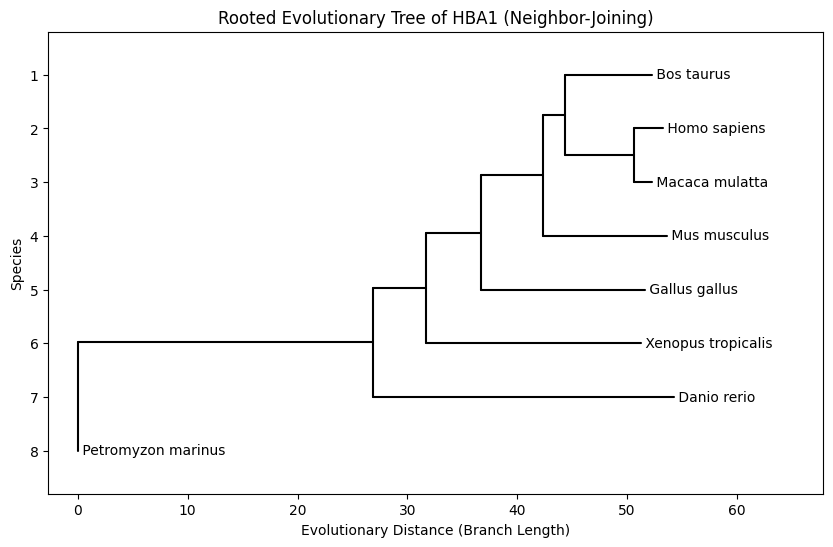

In [5]:
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor
from Bio import Phylo
import matplotlib.pyplot as plt

target_gene = "HBA1"
species_list = list(accession_db[target_gene].keys())
num_species = len(species_list)

print(f"Calculating lower-triangular distance matrix for {target_gene}...")

lower_triangular_matrix = []
for i in range(num_species):
    row = []
    for j in range(i + 1):
        if i == j:
            row.append(0.0)
        else:
            dist = get_distance(sequences[target_gene][species_list[i]], sequences[target_gene][species_list[j]])
            row.append(dist)
    lower_triangular_matrix.append(row)

dist_matrix = DistanceMatrix(names=species_list, matrix=lower_triangular_matrix)

constructor = DistanceTreeConstructor()
nj_tree = constructor.nj(dist_matrix)

# Explicitly root the tree using the outgroup
nj_tree.root_with_outgroup({"name": "Petromyzon marinus"})

fig, ax = plt.subplots(figsize=(10, 6))

# Updated label_func to hide internal node names like "Inner1"
Phylo.draw(nj_tree, axes=ax, do_show=False, label_func=lambda clade: clade.name if clade.is_terminal() else "")

plt.title(f"Rooted Evolutionary Tree of {target_gene} (Neighbor-Joining)")
plt.xlabel("Evolutionary Distance (Branch Length)")
plt.ylabel("Species")
plt.show()

### Homework: Comparative Conservation Rates and Selective Pressure

**Background:**
Different proteins evolve at different rates depending on their biological function. A mutation in a critical structural enzyme might be fatal, removing the mutation from the gene pool (high selective pressure). A mutation in a temporary biological byproduct might have no effect, allowing mutations to accumulate rapidly without harming the organism (low selective pressure).

**The Task:**
You will analyze the evolutionary divergence of three proteins across eight vertebrate species to determine their relative selective pressures.

1. **Cytochrome C (CYCS):** A core enzyme in the mitochondrial electron transport chain essential for cellular respiration.
2. **Hemoglobin $\alpha$ (HBA1):** A subunit of the oxygen transport protein in red blood cells.
3. **Fibrinopeptide A (FGA):** A small peptide cleaved off and discarded during blood clot formation.

**Instructions:**
1. Using the `calculate_identity()` function, calculate the pairwise sequence identity between *Homo sapiens* and the other 7 species for all three genes.
2. Use the provided `divergence_mya` dictionary (Millions of Years Ago) as your X-axis data.
3. Plot a single Matplotlib figure with Sequence Identity (%) on the Y-axis and Divergence Time (MYA) on the X-axis. Plot all three genes using different colors.
4. Use `numpy.polyfit` to calculate and plot a linear regression trendline for each gene.
5. Print the calculated slope for each gene.

**Analysis Questions:**
1. Based on the slopes of your regression lines, rank the three proteins from most conserved (slowest evolution) to least conserved (fastest evolution).
2. Explain the biological reasoning for this ranking based on the known functions of CYCS, HBA1, and FGA.

CYCS Regression Slope: -0.0735 % per million years
HBA1 Regression Slope: -0.0881 % per million years
FGA Regression Slope: -0.0665 % per million years


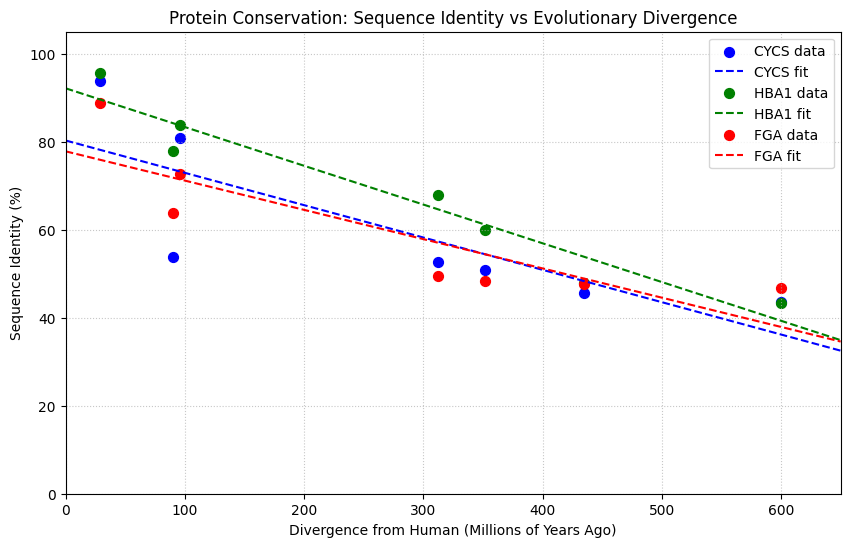

In [6]:
import numpy as np
import matplotlib.pyplot as plt

genes = ["CYCS", "HBA1", "FGA"]
colors = {"CYCS": "blue", "HBA1": "green", "FGA": "red"}

plt.figure(figsize=(10, 6))

for gene in genes:
    x_mya = []
    y_identity = []

    human_seq = sequences[gene]["Homo sapiens"]

    # Exclude human from the loop to avoid plotting the 0 MYA / 100% identity anchor point
    for organism in divergence_mya.keys():
        if organism == "Homo sapiens":
            continue

        mya = divergence_mya[organism]
        target_seq = sequences[gene][organism]

        identity = calculate_identity(human_seq, target_seq)

        x_mya.append(mya)
        y_identity.append(identity)

    # Scatter plot of raw identities
    plt.scatter(x_mya, y_identity, label=f"{gene} data", color=colors[gene], s=50)

    # Calculate linear regression (degree 1 polynomial)
    m, b = np.polyfit(x_mya, y_identity, 1)

    # Generate line coordinates for plotting
    x_line = np.array([0, 650])
    y_line = m * x_line + b

    # Plot trendline
    plt.plot(x_line, y_line, color=colors[gene], linestyle='--', label=f"{gene} fit")

    print(f"{gene} Regression Slope: {m:.4f} % per million years")

plt.title("Protein Conservation: Sequence Identity vs Evolutionary Divergence")
plt.xlabel("Divergence from Human (Millions of Years Ago)")
plt.ylabel("Sequence Identity (%)")
plt.xlim(0, 650)
plt.ylim(0, 105)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [7]:
!pip install -q geopandas

[Bat CoV (Outgroup)] downloaded: 29855 bp
[Wuhan, China] downloaded: 29903 bp
[Lombardy, Italy] downloaded: 29867 bp
[Valencia, Spain] downloaded: 29782 bp
[New York, USA] downloaded: 1007 bp
[Washington, USA] downloaded: 29882 bp
[Victoria, Aus] downloaded: 29893 bp

Calculating all-vs-all sequence alignments (this may take a minute)...
Calculated Bat CoV (Outgroup) vs Wuhan, China: 3.8655
Calculated Bat CoV (Outgroup) vs Lombardy, Italy: 3.8765
Calculated Bat CoV (Outgroup) vs Valencia, Spain: 3.8775
Calculated Bat CoV (Outgroup) vs New York, USA: 52.2388
Calculated Bat CoV (Outgroup) vs Washington, USA: 3.8554
Calculated Bat CoV (Outgroup) vs Victoria, Aus: 3.9023
Calculated Wuhan, China vs Lombardy, Italy: 0.0100
Calculated Wuhan, China vs Valencia, Spain: 0.0269
Calculated Wuhan, China vs New York, USA: 52.2423
Calculated Wuhan, China vs Washington, USA: 0.0100
Calculated Wuhan, China vs Victoria, Aus: 0.0435
Calculated Lombardy, Italy vs Valencia, Spain: 0.0369
Calculated Lombard

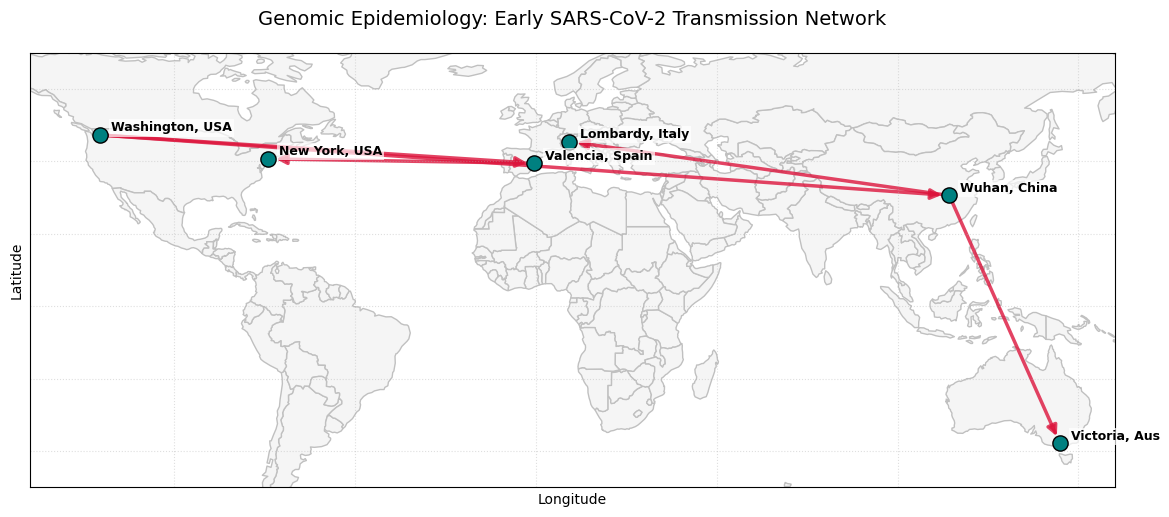

In [12]:
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
from Bio import Entrez, SeqIO, Align
import time

Entrez.email = "instructor@example.com"

# The real dataset with NCBI accessions and coordinates
nodes = {
    "Bat CoV (Outgroup)": {"acc": "MN996532.2", "coords": (101.4, 25.0)},
    "Wuhan, China":       {"acc": "NC_045512.2", "coords": (114.3, 30.6)},
    "Lombardy, Italy":    {"acc": "MT066156.1",  "coords": (9.2, 45.5)},
    "Valencia, Spain":    {"acc": "MT198652.2",  "coords": (-0.4, 39.5)},
    "New York, USA":      {"acc": "MT233282.1",  "coords": (-74.0, 40.7)},
    "Washington, USA":    {"acc": "MT020880.1",  "coords": (-120.5, 47.3)},
    "Victoria, Aus":      {"acc": "MT007544.1",  "coords": (144.9, -37.8)}
}

# 1. Download the real sequences
print("Downloading viral genomes from NCBI...")
sequences = {}
for name, data in nodes.items():
    try:
        handle = Entrez.efetch(db="nucleotide", id=data["acc"], rettype="fasta", retmode="text")
        sequences[name] = SeqIO.read(handle, "fasta").seq
        print(f"[{name}] downloaded: {len(sequences[name])} bp")
        time.sleep(0.5)
    except Exception as e:
        print(f"[{name}] failed: {e}")

# 2. Configure the aligner
aligner = Align.PairwiseAligner()
aligner.mode = 'local'
aligner.match_score = 5
aligner.mismatch_score = -4
aligner.open_gap_score = -10
aligner.extend_gap_score = -1

def get_distance(seq1, seq2):
    best_alignment = aligner.align(seq1, seq2)[0]
    matches = str(best_alignment).count("|")
    aligned_length = best_alignment.shape[1]
    identity = (matches / aligned_length) * 100
    return 100.0 - identity

# 3. Build Graph and calculate ALL real edges dynamically
print("\nCalculating all-vs-all sequence alignments (this may take a minute)...")
G = nx.Graph()
for node_name, data in nodes.items():
    G.add_node(node_name, pos=data["coords"])

node_names = list(nodes.keys())
for i in range(len(node_names)):
    for j in range(i + 1, len(node_names)):
        u = node_names[i]
        v = node_names[j]

        # Calculate real biological distance
        dist = get_distance(sequences[u], sequences[v])
        G.add_edge(u, v, weight=dist)
        print(f"Calculated {u} vs {v}: {dist:.4f}")

# 4. Compute the Minimum Spanning Tree from real data
mst = nx.minimum_spanning_tree(G)

# 5. Direct the network away from the root (Outgroup's neighbor)
outgroup = "Bat CoV (Outgroup)"
root_node = list(mst.neighbors(outgroup))[0]
mst.remove_node(outgroup)

directed_mst = nx.DiGraph()
for node in mst.nodes():
    directed_mst.add_node(node, pos=mst.nodes[node]['pos'])

directed_edges = list(nx.bfs_edges(mst, source=root_node))
directed_mst.add_edges_from(directed_edges)

# 6. Plotting
print("\nPlotting transmission network...")
fig, ax = plt.subplots(figsize=(14, 8))

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)
world.plot(ax=ax, color='whitesmoke', edgecolor='silver')

pos = nx.get_node_attributes(directed_mst, 'pos')

nx.draw_networkx_edges(
    directed_mst, pos, ax=ax,
    edge_color='crimson', width=2.5, alpha=0.8,
    arrows=True, arrowstyle='-|>', arrowsize=15,
    node_size=120
)

nx.draw_networkx_nodes(directed_mst, pos, ax=ax, node_color='teal', node_size=120, edgecolors='black')

for node, (lon, lat) in pos.items():
    ax.text(lon + 3, lat + 1, node, fontsize=9, fontweight='bold', color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5))

plt.title("Genomic Epidemiology: Early SARS-CoV-2 Transmission Network", pad=20, fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-140, 160)
plt.ylim(-50, 70)
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()